In [9]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

import warnings

warnings.filterwarnings('ignore')

# <u>K Means Clustering</u> 

### Steps :

1. Decide How many clusters you want that is `K`.
2. Initialize Centroids - Selecting `K` random points to be the centroids of the Clusters.
3. Assign Clusters to Points - By calculating the Euclidian Distance.
4. Move Centroids - After assigning the clusters to the points all the centroids are moved to the `Mean of the Clusters`.
5. Finish - When there are no change in the centroids. 

<Axes: >

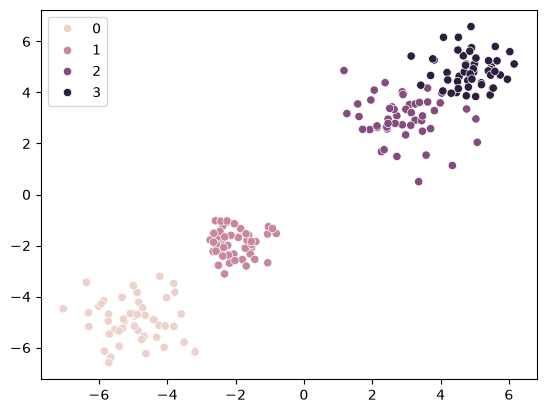

In [ ]:
centroids = [(-5,-5), (-2,-2), (3,3), (5,5)]
cluster_std = [0.8,0.5,0.9,0.7]

X, y = make_blobs(n_samples=200, n_features=2, centers=centroids, cluster_std=cluster_std, random_state=0)

sns.scatterplot(x = X[:,0], y = X[:,1], hue=y)

### How to Select the Number of Clusters?

### We use the `Elbow Method`

In this method we draw the Elbow Curve between Within Cluster Sum of Squares (WCSS) and No. of Clusters and when the curve starts to stabalize that point is called the `Elbow Point` at that point whatever is the # Clusters will be selected.

### WCSS : It is the sum of squared distances of the points from there centroids.

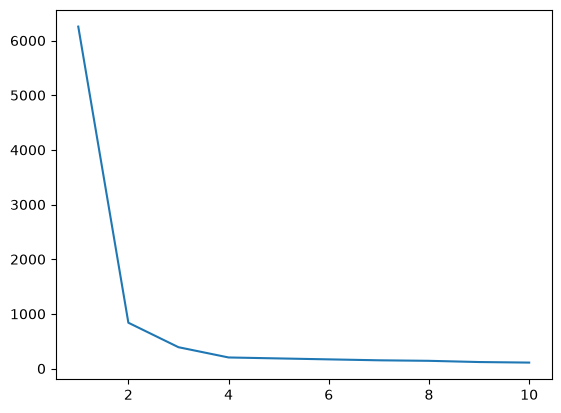

In [10]:
wcss = []

for i in range(1,11):
    km = KMeans(n_clusters=i)
    km.fit_predict(X)
    wcss.append(km.inertia_)

plt.plot(range(1,11), wcss)

### The Elbow point is at 4 Clusters

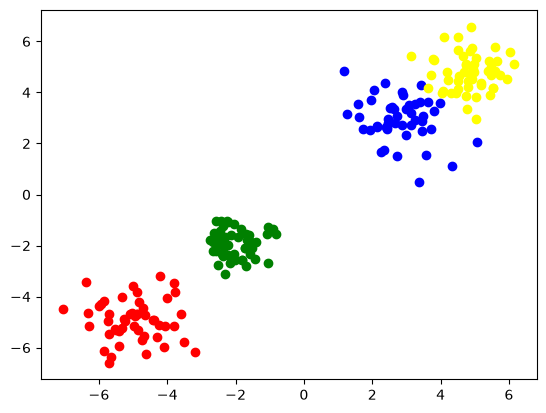

In [12]:
km = KMeans(n_clusters=4)
y_mean = km.fit_predict(X)

plt.scatter(X[y_mean == 0,0], X[y_mean == 0,1], color = 'red')
plt.scatter(X[y_mean == 1,0], X[y_mean == 1,1], color = 'blue')
plt.scatter(X[y_mean == 2,0], X[y_mean == 2,1], color = 'green')
plt.scatter(X[y_mean == 3,0], X[y_mean == 3,1], color = 'yellow')
plt.show()

<Axes: >

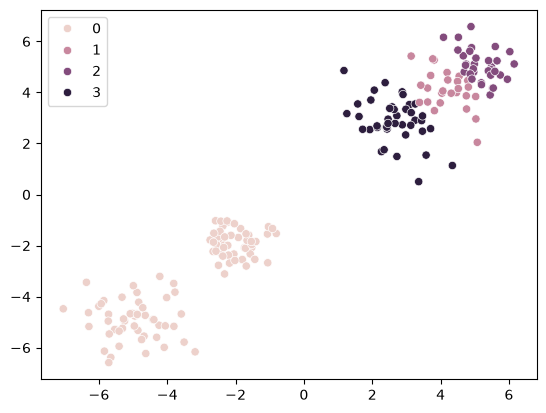

In [40]:
class MyKMean:

    def __init__(self, n_clusters = 2, max_iter = 100):

        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None

    def fit_predict(self, X):
        # Initialize Centroids
        idx = np.random.randint(0, X.shape[0], self.n_clusters)
        self.centroids = X[idx]

        for i in range(self.max_iter):

            # Assign Clusters
            cluster_group = self.assign_clusters(X)

            old_centroids = self.centroids

            # Move Centroids
            self.centroids = self.move_centroids(X, cluster_group)

            # Finish
            if(old_centroids == self.centroids).all():
                break

        return cluster_group
    
    def assign_clusters(self, X):

        cluster_group = []
        distances = []

        for row in X:
            for centroid in self.centroids:
                distances.append(np.sqrt(np.dot(row - centroid, row - centroid)))
            min_distance = min(distances)
            idx_pos = distances.index(min_distance)
            cluster_group.append(idx_pos)
            distances.clear()
        return np.array(cluster_group)

    def move_centroids(self, X, cluster_group):
        new_centroids = []

        cluster_types = np.unique(cluster_group)

        for type in cluster_types:
            new_centroids.append(X[cluster_group == type].mean(axis = 0))

        return np.array(new_centroids)



km = MyKMean(n_clusters=4)

y_mean = km.fit_predict(X)

sns.scatterplot(x = X[:,0], y = X[:,1], hue=y_mean)